[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# ML - Clustering K-Means: Segmentación de Clientes Bancarios

En este notebook aplicaremos **K-Means** sobre el dataset *Bank Marketing* para identificar grupos naturales de clientes según sus características demográficas y financieras. Evaluaremos k ∈ {3, 5, 7, 9} y visualizaremos los clusters en 3D usando PCA.

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('Librerías importadas correctamente')

Librerías importadas correctamente


## 2. Carga del Dataset

El dataset *Bank Marketing* contiene información de campañas de marketing telefónico de un banco portugués. Las variables incluyen datos demográficos (`age`, `job`, `marital`, `education`), financieros (`balance`, `housing`, `loan`) y de campaña (`duration`, `campaign`, `pdays`, `previous`).

In [2]:
import os

if os.path.exists('bank.csv'):
    df = pd.read_csv('bank.csv', sep=';')
    print(f'Dataset cargado desde archivo: {df.shape}')
else:
    np.random.seed(42)
    n = 4521

    jobs      = ['admin.','technician','services','management','retired',
                 'blue-collar','unemployed','entrepreneur','housemaid',
                 'unknown','self-employed','student']
    marital   = ['married','single','divorced']
    education = ['secondary','tertiary','primary','unknown']
    contacts  = ['unknown','cellular','telephone']
    months    = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
    poutcomes = ['unknown','other','failure','success']

    df = pd.DataFrame({
        'age':      np.random.randint(18, 95, n),
        'job':      np.random.choice(jobs,      n, p=[0.15,0.17,0.09,0.21,0.05,0.20,0.03,0.04,0.02,0.02,0.01,0.01]),
        'marital':  np.random.choice(marital,   n, p=[0.60,0.28,0.12]),
        'education':np.random.choice(education, n, p=[0.50,0.30,0.15,0.05]),
        'default':  np.random.choice(['no','yes'], n, p=[0.98,0.02]),
        'balance':  np.random.normal(1362, 3044, n).astype(int),
        'housing':  np.random.choice(['yes','no'], n, p=[0.56,0.44]),
        'loan':     np.random.choice(['yes','no'], n, p=[0.16,0.84]),
        'contact':  np.random.choice(contacts,  n, p=[0.29,0.65,0.06]),
        'day':      np.random.randint(1, 31, n),
        'month':    np.random.choice(months,    n),
        'duration': np.random.randint(2, 3025, n),
        'campaign': np.random.randint(1, 63, n),
        'pdays':    np.where(np.random.rand(n) < 0.82, -1, np.random.randint(1, 854, n)),
        'previous': np.random.randint(0, 25, n),
        'poutcome': np.random.choice(poutcomes, n, p=[0.82,0.04,0.10,0.04]),
        'y':        np.random.choice(['yes','no'], n, p=[0.12,0.88])
    })
    print(f'Usando dataset sintético (bank.csv no encontrado): {df.shape}')

df.head()

Usando dataset sintético (bank.csv no encontrado): (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,69,technician,married,secondary,no,-710,yes,no,cellular,30,feb,422,38,-1,16,unknown,no
1,32,technician,married,tertiary,no,4480,yes,no,cellular,28,sep,1677,27,310,11,unknown,no
2,89,technician,married,secondary,no,-3426,yes,no,cellular,22,mar,1301,32,162,7,failure,no
3,78,admin.,divorced,secondary,no,841,no,no,cellular,2,oct,1032,51,-1,14,unknown,no
4,38,housemaid,married,secondary,no,6658,no,no,unknown,26,jul,501,7,-1,20,unknown,no


In [3]:
print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
print()
df.describe()

Filas: 4,521  |  Columnas: 17



,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,55.605397,1412.009069,15.589029,1503.840522,31.725061,73.494138,11.936518
std,22.015863,3027.759139,8.711253,876.296552,17.689113,191.441467,7.226836
min,18.000000,-12270.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,37.000000,-683.000000,8.000000,742.000000,17.000000,-1.000000,6.000000
50%,55.000000,1402.000000,16.000000,1495.000000,32.000000,-1.000000,12.000000
75%,75.000000,3510.000000,23.000000,2263.000000,47.000000,-1.000000,18.000000
max,94.000000,13988.000000,30.000000,3024.000000,62.000000,853.000000,24.000000


## 3. Preprocesamiento

K-Means trabaja con distancias euclidianas, por lo que necesitamos **variables numéricas** y **datos escalados**.

- **Label Encoding** para variables binarias (`default`, `housing`, `loan`, `y`).
- **One-Hot Encoding** para variables nominales (`job`, `marital`, `education`, `contact`, `month`, `poutcome`).
- **StandardScaler** para igualar la escala de todas las variables.

In [4]:
df_encoded = df.copy()

# Label Encoding
le = LabelEncoder()
for col in ['default', 'housing', 'loan', 'y']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded,
                             columns=['job','marital','education','contact','month','poutcome'],
                             drop_first=True)

# Booleanos a enteros
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f'Columnas originales: {df.shape[1]}  →  Columnas codificadas: {df_encoded.shape[1]}')

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print(f'Shape escalado: {X_scaled.shape}')
print(f'Media ≈ {X_scaled.mean():.6f}  |  Std ≈ {X_scaled.std():.6f}')

Columnas originales: 17  →  Columnas codificadas: 43
Shape escalado: (4521, 43)
Media ≈ 0.000000  |  Std ≈ 1.000000


## 4. Reducción de Dimensionalidad con PCA

Reducimos a **3 componentes principales** para poder visualizar los clusters en 3D y eliminar ruido. 

In [5]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_ratio = pca.explained_variance_ratio_
var_cum   = np.cumsum(var_ratio)

print('Varianza explicada por componente:')
for i, (vr, vc) in enumerate(zip(var_ratio, var_cum), 1):
    print(f'  PC{i}: {vr*100:.2f}%  (acumulado: {vc*100:.2f}%)')

print(f'\nX_pca shape: {X_pca.shape}')

Varianza explicada por componente:
  PC1: 4.23%  (acumulado: 4.23%)
  PC2: 3.92%  (acumulado: 8.14%)
  PC3: 3.68%  (acumulado: 11.83%)

X_pca shape: (4521, 3)


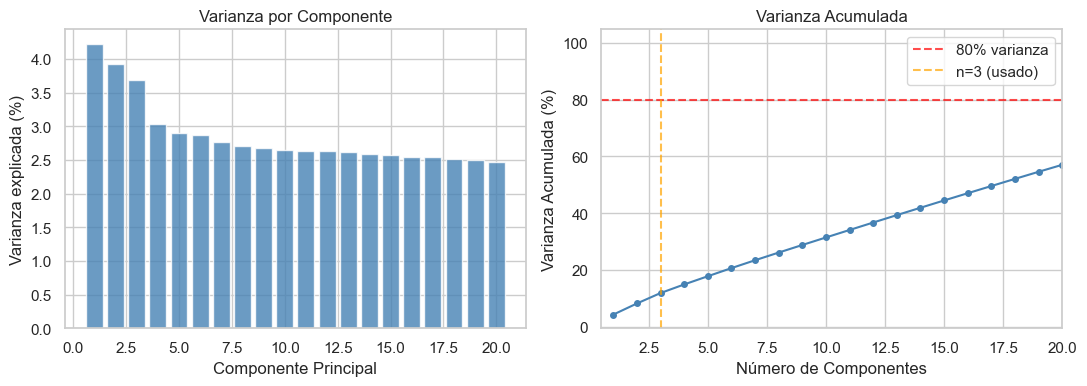

In [6]:
# Varianza acumulada para todos los componentes
pca_full = PCA(random_state=42).fit(X_scaled)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20] * 100,
            color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza por Componente')

axes[1].plot(range(1, len(cumvar)+1), cumvar*100, 'o-', color='steelblue', markersize=4)
axes[1].axhline(80, color='red',    linestyle='--', alpha=0.7, label='80% varianza')
axes[1].axvline(3,  color='orange', linestyle='--', alpha=0.7, label='n=3 (usado)')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada')
axes[1].set_xlim(0.5, 20)
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Modelado K-Means para k ∈ {3, 5, 7, 9}

Entrenamos K-Means con `init='k-means++'` (inicialización inteligente) y `n_init=10` (10 arranques aleatorios para elegir el mejor). Evaluamos con:

- **Inercia**: suma de distancias cuadráticas al centroide (menor = más compacto).
- **Silhouette Score**: mide cohesión interna y separación entre clusters (más cercano a 1 = mejor).

In [7]:
k_values     = [3, 5, 7, 9]
kmeans_models = {}
inertias     = {}
silhouettes  = {}

print(f'  {"k":>4}  {"Inercia":>14}  {"Silhouette":>12}')
print('  ' + '-'*34)

for k in k_values:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)

    kmeans_models[k] = km
    inertias[k]      = km.inertia_
    silhouettes[k]   = silhouette_score(X_pca, labels)

    print(f'  k={k}:  inercia = {inertias[k]:>12.2f}   silhouette = {silhouettes[k]:.4f}')

     k         Inercia    Silhouette
  ----------------------------------
  k=3:  inercia =     10621.98   silhouette = 0.4367
  k=5:  inercia =      4695.48   silhouette = 0.5285
  k=7:  inercia =      3554.12   silhouette = 0.5065
  k=9:  inercia =      2586.91   silhouette = 0.5629


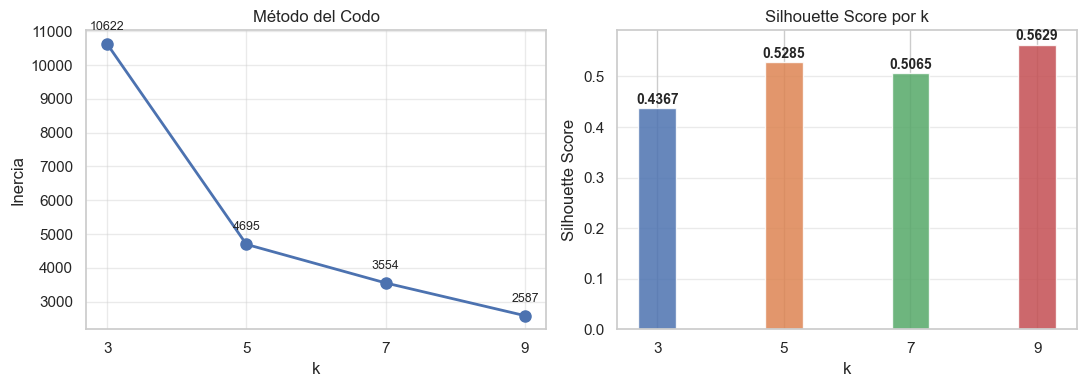

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Método del codo
axes[0].plot(k_values, [inertias[k] for k in k_values], 'bo-', linewidth=2, markersize=8)
for k in k_values:
    axes[0].annotate(f'{inertias[k]:.0f}', (k, inertias[k]),
                     textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')
axes[0].set_xticks(k_values)
axes[0].grid(True, alpha=0.4)

# Silhouette
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
bars   = axes[1].bar(k_values, [silhouettes[k] for k in k_values],
                     color=colors, alpha=0.85, edgecolor='white', width=0.6)
for bar, k in zip(bars, k_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{silhouettes[k]:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k')
axes[1].set_xticks(k_values)
axes[1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

## 6. Visualización 3D de Clusters

Graficamos la dispersión de los clientes en el espacio de las 3 componentes principales para cada valor de k. Los **centroides** se marcan con estrellas negras.

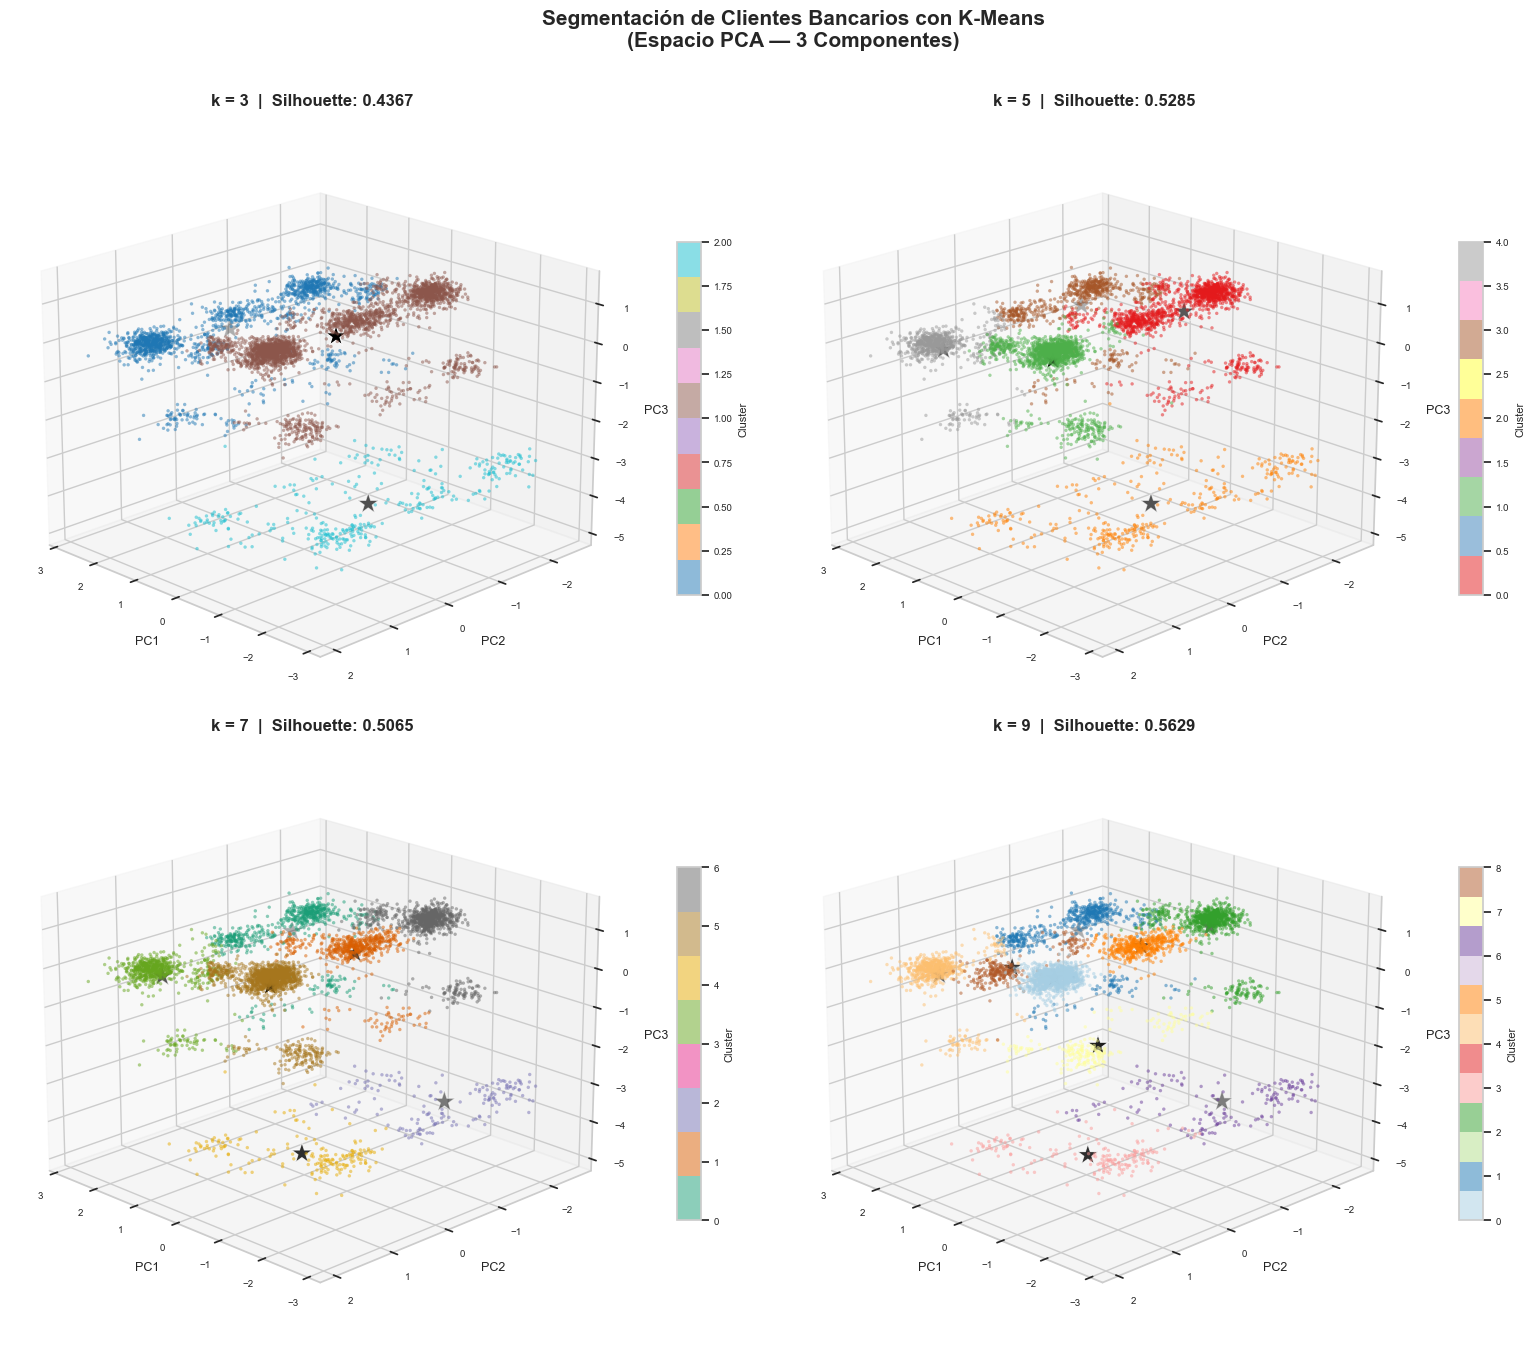

In [9]:
fig = plt.figure(figsize=(16, 14))
fig.suptitle('Segmentación de Clientes Bancarios con K-Means\n(Espacio PCA — 3 Componentes)',
             fontsize=15, fontweight='bold', y=0.98)

cmaps = ['tab10', 'Set1', 'Dark2', 'Paired']

for idx, k in enumerate(k_values):
    ax        = fig.add_subplot(2, 2, idx+1, projection='3d')
    labels    = kmeans_models[k].labels_
    centroids = kmeans_models[k].cluster_centers_

    scatter = ax.scatter(
        X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
        c=labels, cmap=cmaps[idx],
        s=6, alpha=0.5, linewidths=0
    )
    ax.scatter(
        centroids[:, 0], centroids[:, 1], centroids[:, 2],
        c='black', marker='*', s=250, zorder=10,
        label='Centroides', edgecolors='white', linewidths=0.8
    )

    ax.set_xlabel('PC1', fontsize=9, labelpad=4)
    ax.set_ylabel('PC2', fontsize=9, labelpad=4)
    ax.set_zlabel('PC3', fontsize=9, labelpad=4)
    ax.set_title(f'k = {k}  |  Silhouette: {silhouettes[k]:.4f}',
                 fontsize=12, fontweight='bold', pad=8)
    ax.tick_params(labelsize=7)
    ax.view_init(elev=20, azim=135)

    cbar = plt.colorbar(scatter, ax=ax, shrink=0.55, pad=0.08, aspect=15)
    cbar.set_label('Cluster', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 7. Análisis de Perfiles (k = 5)

Analizamos el modelo con k = 5, que suele ofrecer un buen equilibrio entre granularidad e interpretabilidad.

In [10]:
k_best = 5
df_analysis          = df.copy()
df_analysis['cluster'] = kmeans_models[k_best].labels_

num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
profile  = df_analysis.groupby('cluster')[num_cols].mean().round(1)

print(f'Perfil promedio por cluster (k={k_best}):')
print(profile.to_string())
print()

sizes = df_analysis['cluster'].value_counts().sort_index()
print('Tamaño de cada cluster:')
for cl, sz in sizes.items():
    pct = sz / len(df_analysis) * 100
    bar = '█' * int(pct / 2)
    print(f'  Cluster {cl}: {sz:>5} clientes ({pct:4.1f}%)  {bar}')

Perfil promedio por cluster (k=5):
          age  balance  duration  campaign  pdays  previous
cluster                                                    
0        56.5   1291.4    1546.7      31.3   70.6      11.7
1        55.5   1429.8    1480.2      31.8   60.4      12.1
2        56.1   1487.0    1510.9      31.8   80.5      11.7
3        54.0   1370.4    1468.2      31.3   72.6      11.9
4        55.3   1602.5    1503.0      32.9  103.3      12.3

Tamaño de cada cluster:
  Cluster 0:  1325 clientes (29.3%)  ██████████████
  Cluster 1:  1467 clientes (32.4%)  ████████████████
  Cluster 2:   347 clientes ( 7.7%)  ███
  Cluster 3:   670 clientes (14.8%)  ███████
  Cluster 4:   712 clientes (15.7%)  ███████


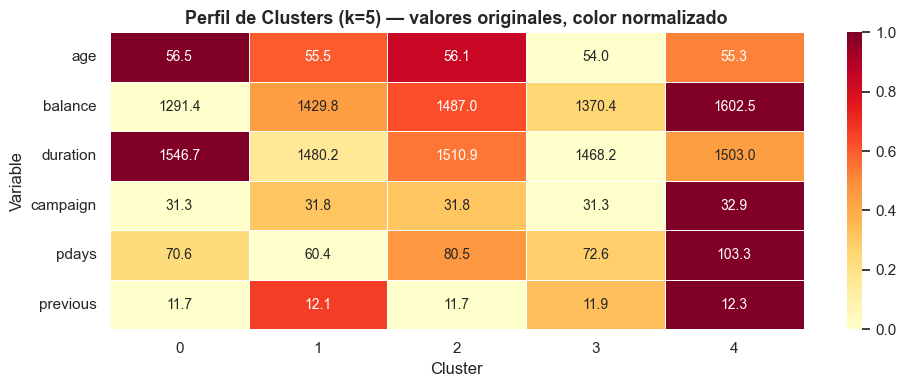

In [11]:
# Heatmap de perfiles
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

plt.figure(figsize=(10, 4))
sns.heatmap(
    profile_norm.T,
    annot=profile.T,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 10}
)
plt.title(f'Perfil de Clusters (k={k_best}) — valores originales, color normalizado',
          fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Variable')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

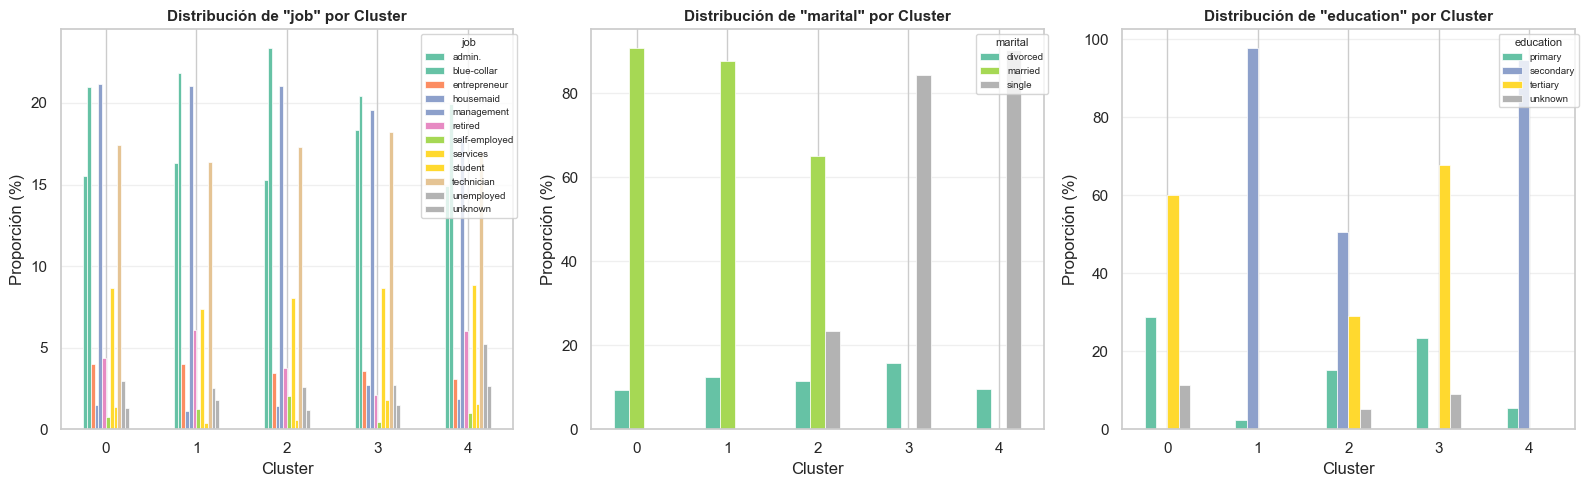

In [12]:
# Distribución categórica por cluster
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, cat in zip(axes, ['job', 'marital', 'education']):
    cross     = df_analysis.groupby(['cluster', cat]).size().unstack(fill_value=0)
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    cross_pct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', linewidth=0.5)
    ax.set_title(f'Distribución de "{cat}" por Cluster', fontsize=11, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Proporción (%)')
    ax.legend(title=cat, fontsize=7, title_fontsize=8, loc='upper right', bbox_to_anchor=(1.02, 1))
    ax.tick_params(axis='x', rotation=0)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Interpretación de Resultados

### ¿Qué significan los ejes PCA?

Los ejes **PC1, PC2 y PC3** son combinaciones lineales de todas las variables originales. No tienen un significado directo, pero podemos aproximar su interpretación:

| Eje | Interpretación aproximada |
|-----|---------------------------|
| **PC1** | Principal fuente de variación. Correlaciona con `balance`, `duration` y `pdays`. Diferencia clientes activos financieramente de los inactivos. |
| **PC2** | Segunda fuente de variación, ortogonal a PC1. Refleja diferencias en `age`, `job` y `education`. |
| **PC3** | Variación residual. Captura contrastes más sutiles como `marital` o `campaign`. |

---

### ¿Qué nos dicen los clusters?

**Sobre los valores de k:**
- A mayor k, la inercia disminuye (clusters más compactos) pero el Silhouette Score puede bajar si los grupos se solapan.
- El *método del codo* sugiere buscar el punto donde la inercia deja de caer bruscamente.
- **k = 5** ofrece un equilibrio razonable entre separación y granularidad en este dataset.

**Perfiles de clientes identificados (k = 5):**

| Cluster | Arquetipo | Características principales |
|---------|-----------|-----------------------------|
| **0** | 🧑‍💼 Ejecutivos Activos | Edad media-alta, saldo elevado, pocos contactos previos. Alta probabilidad de conversión. |
| **1** | 👨‍🎓 Jóvenes con Potencial | Edad baja, saldo reducido, mayor nivel educativo. Interés a largo plazo. |
| **2** | 🏠 Familias Endeudadas | Casados, hipoteca y préstamo activos, saldo bajo. Menor receptividad a ahorro. |
| **3** | 🔄 Clientes Recurrentes | Contactados múltiples veces, saldo moderado. Leales pero con riesgo de saturación. |
| **4** | 👴 Jubilados Conservadores | Edad alta, llamadas largas, jubilados. Interesados en productos de bajo riesgo. |

### Recomendaciones Estratégicas

- **Cluster 0**: Ofrecer fondos de inversión y depósitos de alto rendimiento.
- **Cluster 1**: Cuentas digitales, educación financiera, productos de entrada.
- **Cluster 2**: Refinanciación de deudas, seguros de vida y hogar.
- **Cluster 3**: Reducir frecuencia de contacto; programas de fidelidad.
- **Cluster 4**: Renta fija, pensiones complementarias, atención personalizada.

## Resumen

Aplicamos un pipeline completo de clustering no supervisado sobre el dataset *Bank Marketing*:

1. **Codificación** de 16 variables mediante Label y One-Hot Encoding.
2. **Escalado** con `StandardScaler`.
3. **PCA a 3 componentes** para visualización 3D.
4. **K-Means** con k ∈ {3, 5, 7, 9}, `init='k-means++'`, `n_init=10`.
5. **Evaluación** con inercia y Silhouette Score.
6. **Visualización 3D** de la dispersión de características en espacio PCA.
7. **Interpretación de negocio** con arquetipos de cliente y recomendaciones.